In [29]:
import pandas as pd
import numpy as np

data=pd.read_csv("loanapproval.csv")

In [30]:
data.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [31]:
data = data.drop("applicant_id", axis=1)

In [32]:
data.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,49,Male,Married,112197,23556,789,0,2,Employed,1
2,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [33]:
# print the missing value 

print(data.isnull().sum())

age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64


In [34]:
# describe the rows and column number

data.shape

(1000, 10)

In [35]:
# describe the statictical measure

data.describe()

,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,42.515000,81972.972000,27244.866000,576.125000,1.97700,2.042000,0.729000
std,12.611059,37547.255418,12822.752877,155.921483,1.41862,1.413589,0.444699
min,21.000000,20155.000000,5082.000000,300.000000,0.00000,0.000000,0.000000
25%,32.000000,48913.250000,16587.500000,443.750000,1.00000,1.000000,0.000000
50%,43.000000,82050.000000,27041.500000,573.500000,2.00000,2.000000,1.000000
75%,53.000000,113556.000000,37939.250000,713.250000,3.00000,3.000000,1.000000
max,64.000000,149951.000000,49864.000000,849.000000,4.00000,4.000000,1.000000


In [36]:
data.drop_duplicates(inplace=True)

In [37]:
data.shape

(1000, 10)

In [38]:
# dependent column value 

data.value_counts()


age  gender  marital_status  annual_income  loan_amount  credit_score  num_dependents  existing_loans_count  employment_status  loan_approved
21   Female  Divorced        115804         17869        533           3               4                     Employed           0                1
50   Male    Married         68515          27520        407           1               1                     Employed           1                1
     Female  Divorced        57051          5276         443           2               1                     Self-employed      1                1
                             66305          13682        480           3               4                     Self-employed      0                1
                             74400          22908        657           2               0                     Unemployed         1                1
                                                                                                                           

Text(0.5, 1.0, 'Loan Approval Status vs Employment Status')

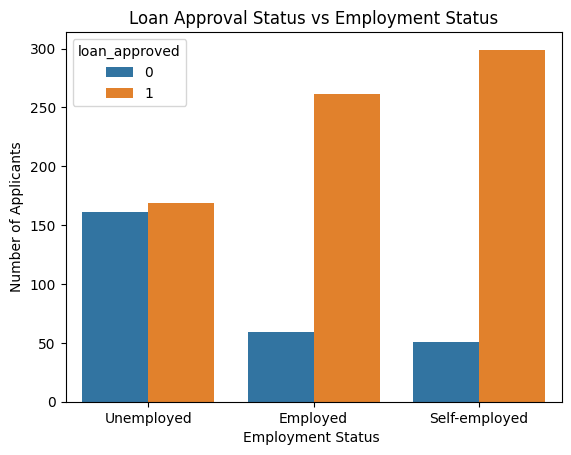

In [39]:
#draw graph for practic and visualize

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x = "employment_status" , hue = "loan_approved", data = data)

plt.xlabel("Employment Status ")
plt.ylabel("Number of Applicants")
plt.title("Loan Approval Status vs Employment Status")

Text(0.5, 1.0, 'Loan Approval Status vs marital_status')

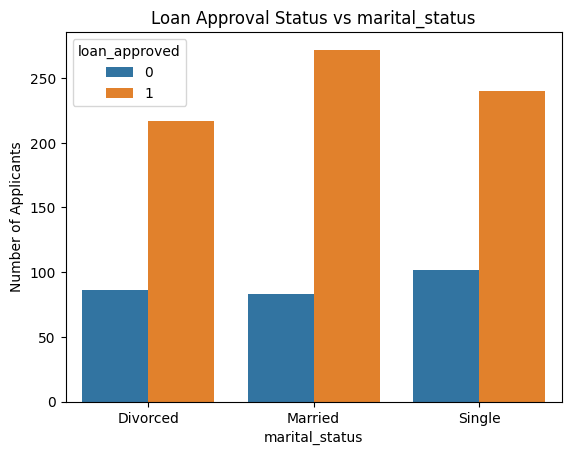

In [40]:
sns.countplot(x = "marital_status" , hue = "loan_approved", data = data)

plt.xlabel("marital_status")
plt.ylabel("Number of Applicants")
plt.title("Loan Approval Status vs marital_status")

In [56]:
data['gender'] = data['gender'].map({'Male': 0, 'Female': 1})

data['marital_status'] = data['marital_status'].map({
    'Single': 0,
    'Married': 1,
    'Divorced': 2
})

data['employment_status'] = data['employment_status'].map({
    'Unemployed': 0,
    'Employed': 1,
    'Self-employed': 2
})

In [57]:
data.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved,Gender,Marital_status,Employment_status,income_loan_ratio,loan_income_ratio,dependents_loan_ratio
0,59,0,2,100073,7169,793,1,1,0,1,0,2,0,13.957183,0.071637,3584.50
1,49,0,1,112197,23556,789,0,2,1,1,0,1,1,4.762788,0.209950,23556.00
2,35,0,2,84429,27052,372,1,4,0,0,0,2,0,3.120874,0.320407,13526.00
3,63,1,0,124195,11313,808,3,4,2,1,1,0,2,10.977108,0.091090,2828.25
4,28,1,1,81627,13315,689,0,1,0,1,1,1,0,6.129994,0.163118,13315.00


In [58]:
data['income_loan_ratio'] = data['annual_income'] / (data['loan_amount'] + 1)
data['loan_income_ratio'] = data['loan_amount'] / (data['annual_income'] + 1)
data['dependents_loan_ratio'] = data['loan_amount'] / (data['num_dependents'] + 1)

In [59]:
data.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved,Gender,Marital_status,Employment_status,income_loan_ratio,loan_income_ratio,dependents_loan_ratio
0,59,0,2,100073,7169,793,1,1,0,1,0,2,0,13.957183,0.071637,3584.50
1,49,0,1,112197,23556,789,0,2,1,1,0,1,1,4.762788,0.209950,23556.00
2,35,0,2,84429,27052,372,1,4,0,0,0,2,0,3.120874,0.320407,13526.00
3,63,1,0,124195,11313,808,3,4,2,1,1,0,2,10.977108,0.091090,2828.25
4,28,1,1,81627,13315,689,0,1,0,1,1,1,0,6.129994,0.163118,13315.00


In [60]:
data.info

<bound method DataFrame.info of      age  gender  marital_status  annual_income  loan_amount  credit_score  \
0     59       0               2         100073         7169           793   
1     49       0               1         112197        23556           789   
2     35       0               2          84429        27052           372   
3     63       1               0         124195        11313           808   
4     28       1               1          81627        13315           689   
..   ...     ...             ...            ...          ...           ...   
995   53       1               1         135598         6014           767   
996   22       0               0         139028        15103           662   
997   34       1               1         147517        21986           582   
998   60       1               2          73161        49781           635   
999   60       1               0         141316        35471           461   

     num_dependents  existing_l

In [61]:
from sklearn.model_selection import train_test_split

X =data.drop('loan_approved', axis=1)
Y =data['loan_approved']

In [62]:
X.shape

(1000, 15)

In [63]:
Y.shape

(1000,)

In [64]:
#Split the data

X_train,X_test,Y_train,Y_test =train_test_split(X,Y,test_size=0.2, stratify=Y, random_state=2)

print(X.shape, X_train.shape, X_test.shape)

(1000, 15) (800, 15) (200, 15)


In [65]:
print(X_train.dtypes)

age                        int64
gender                     int64
marital_status             int64
annual_income              int64
loan_amount                int64
credit_score               int64
num_dependents             int64
existing_loans_count       int64
employment_status          int64
Gender                     int64
Marital_status             int64
Employment_status          int64
income_loan_ratio        float64
loan_income_ratio        float64
dependents_loan_ratio    float64
dtype: object


In [66]:
# Logistic Regression is scale-sensitive. Scaling speeds convergence and improves accuracy.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [68]:
# Predict loan approval (0 or 1) on test data
Y_pred = model.predict(X_test)

# Predict probability of approval
Y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted classes:", Y_pred[:10])
print("Predicted probabilities:", Y_prob[:10])


Predicted classes: [1 1 0 0 1 1 0 0 0 1]
Predicted probabilities: [0.98540113 0.98943893 0.0214783  0.03431657 0.88509369 0.54182915
 0.03250309 0.47123502 0.09814443 0.9783146 ]


In [69]:
# Evalution

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))


Accuracy: 0.895
Confusion Matrix:
 [[ 49   5]
 [ 16 130]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.91      0.82        54
           1       0.96      0.89      0.93       146

    accuracy                           0.90       200
   macro avg       0.86      0.90      0.87       200
weighted avg       0.91      0.90      0.90       200



In [72]:
import numpy as np

new_applicant = np.array([[
    35,     # age
    1,      # gender
    1,      # marital_status
    85000,  # annual_income
    15000,  # loan_amount
    720,    # credit_score
    1,      # num_dependents
    0,      # existing_loans_count
    1,      # employment_status

    1,      # Gender
    1,      # Marital_status
    1,      # Employment_status

    85000 / (15000 + 1),     # income_loan_ratio
    15000 / (85000 + 1),     # loan_income_ratio
    15000 / (1 + 1)          # dependents_loan_ratio
]])

In [73]:
new_applicant_scaled = scaler.transform(new_applicant)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [74]:
# make prediction

prediction = model.predict(new_applicant_scaled)
probability = model.predict_proba(new_applicant_scaled)[0][1]

print("Loan Approved?" , "Yes" if prediction[0] == 1 else "No")
print("Approval Probability:", round(probability * 100, 2), "%")


Loan Approved? Yes
Approval Probability: 99.95 %


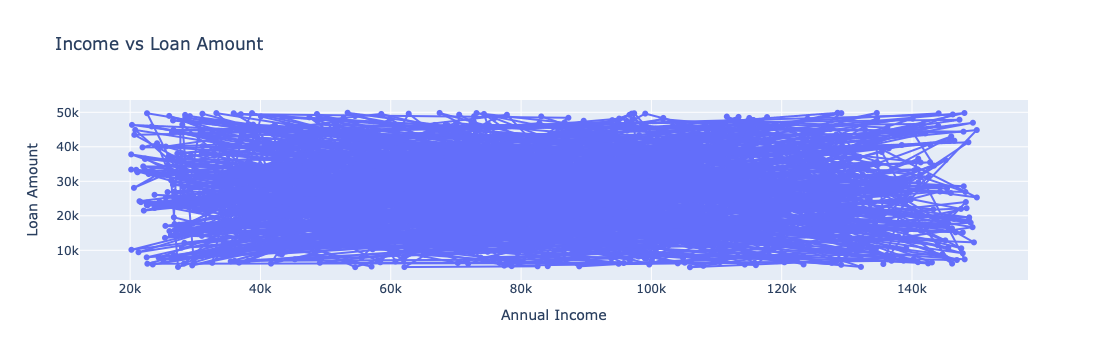

In [86]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data['annual_income'],
    y=data['loan_amount'],
    mode='markers+lines',
    name='Income vs Loan Amount'
))

fig.update_layout(
    title="Income vs Loan Amount",
    xaxis_title="Annual Income",
    yaxis_title="Loan Amount"
)

fig.show()

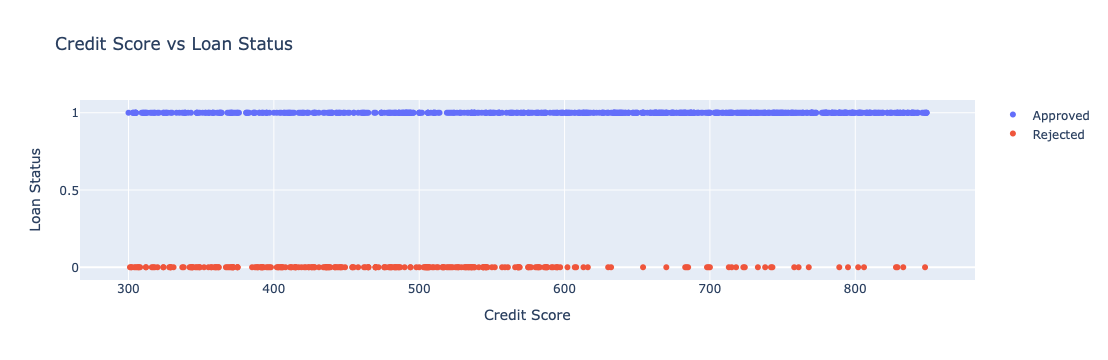

In [85]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data[data['loan_approved']==1]['credit_score'],
    y=data[data['loan_approved']==1]['loan_approved'],
    mode='markers',
    name='Approved'
))

fig.add_trace(go.Scatter(
    x=data[data['loan_approved']==0]['credit_score'],
    y=data[data['loan_approved']==0]['loan_approved'],
    mode='markers',
    name='Rejected'
))

fig.update_layout(
    title="Credit Score vs Loan Status",
    xaxis_title="Credit Score",
    yaxis_title="Loan Status"
)

fig.show()

In [87]:
import pickle

pickle.dump(model, open("loan_model.pkl", "wb"))
pickle.dump(scaler, open("loan_scaler.pkl", "wb"))